In [9]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split as tts 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from imblearn.ensemble import BalancedRandomForestClassifier

import matplotlib.pyplot as plt 
 


In [10]:

# Setting random seed for reproducibility 
np.random.seed(42)

from sklearn.datasets import make_blobs
n_samples_1 = 25 
n_samples_2 = 375 
centers = [(0,0),(2,2)]
cluster_std = [1.5,1.5]


X,y = make_blobs(n_samples=[n_samples_1,n_samples_2],
                 centers=centers, cluster_std=cluster_std, random_state=0)

In [11]:
X_train, X_test, y_train, y_test = tts(X,y, test_size=0.2, random_state=42 )



In [12]:
def plot_decision_boundaries(X,y,model):
    plot_step = 0.02
    X_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min , y_max = X[:,1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(X_min,x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx,yy,Z, alpha=0.3)
    plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()
    

In [13]:
clf =BalancedRandomForestClassifier()

clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


clf report               precision    recall  f1-score   support

           0       0.13      0.50      0.21         4
           1       0.97      0.83      0.89        76

    accuracy                           0.81        80
   macro avg       0.55      0.66      0.55        80
weighted avg       0.93      0.81      0.86        80

ROC-AUC Score:  0.8273026315789473


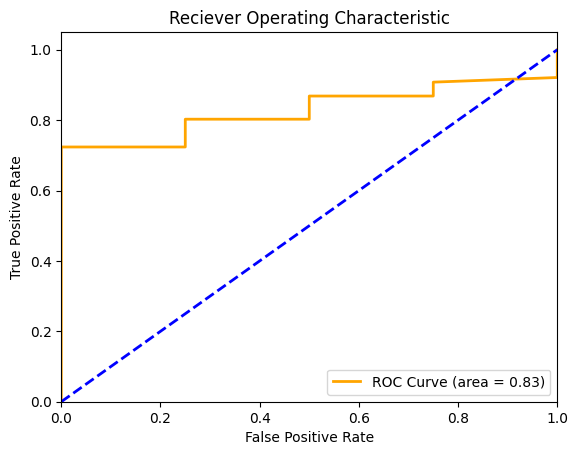

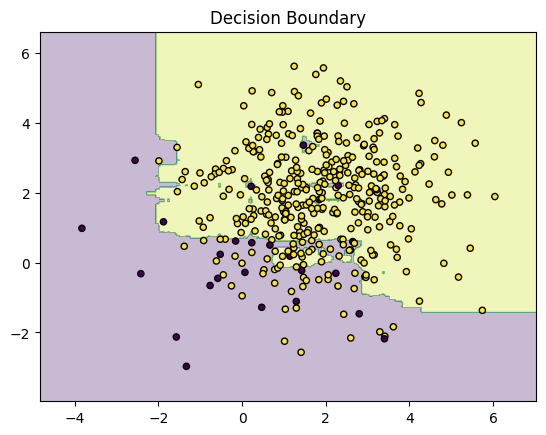

In [14]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print("clf report", classification_report(y_test,y_pred))

print("ROC-AUC Score: ", roc_auc_score(y_test,y_prob))

# plotting ROC-AUC curve

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

plot_decision_boundaries(X,y,clf)